In [1]:
%pip install supervision

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.idi.ntnu.no
Note: you may need to restart the kernel to use updated packages.


### Define paths and describe model

In [15]:
import os
import cv2
import supervision as sv
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # For progress bar
from ultralytics import YOLO
import shutil
import tkinter as tk
from tkinter import simpledialog
import datetime


# -------------  Change these and run all cells -------------------

dir_name = "v12_s_custom_loss_weight=100_retraining" 
train_dir = "/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/yolov12/yolov12/runs/detect/train3"
model = YOLO("/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/yolov12/yolov12/runs/detect/train3/weights/best.pt")
dataset_path = "/home/omtalmo/Olaf_TTK4265/Poles/rgb"
output_dir = f"/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/results/{dir_name}"

# -------------------------------------------------------------------


# Local paths, list creation and folder creation
os.makedirs(output_dir, exist_ok=True)
valid_label_dir = f"{dataset_path}/labels/valid"

test_image_dir = f"{dataset_path}/images/test"
test_images = []
for img in os.listdir(test_image_dir):
    if img.upper().endswith('.PNG') or img.lower().endswith(('.png', '.jpg', '.jpeg')):
        test_images.append(os.path.join(test_image_dir, img))

valid_image_dir = f"{dataset_path}/images/valid"
valid_images = []
for img in os.listdir(valid_image_dir):
    if img.upper().endswith('.PNG') or img.lower().endswith(('.png', '.jpg', '.jpeg')):
        valid_images.append(os.path.join(valid_image_dir, img))

# Copy the contents of the training directory to the output directory
train_output_dir = os.path.join(output_dir, "train_results")
os.makedirs(train_output_dir, exist_ok=True)

# Copy the contents of the training directory
print(f"Copying training results from {train_dir} to {train_output_dir}...")
for item in os.listdir(train_dir):
    s = os.path.join(train_dir, item)
    d = os.path.join(train_output_dir, item)
    if os.path.isdir(s):
        shutil.copytree(s, d, dirs_exist_ok=True)
    else:
        shutil.copy2(s, d)
print("Training results copied successfully!")

# Create a pop-up window to get the run description
# …existing imports and variable definitions above…

def get_run_description():
    """
    Pop up a Tk window to collect a multi-line description.
    If running headless (no $DISPLAY), fall back to console input.
    Always writes run_description.txt in output_dir.
    """
    # capture timestamp early so both branches can use it
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    try:
        # -- GUI branch --
        root = tk.Tk()
        root.title("Run Description")
        root.geometry("600x400")

        # Instruction label
        tk.Label(
            root,
            text="Beskriv modellen. Eller bare spam tastaturet, ditt valg:",
            font=("Arial", 12),
            pady=10,
            padx=10
        ).pack(fill="x")

        # Scrollable text box
        text_frame = tk.Frame(root)
        text_frame.pack(fill="both", expand=True, padx=20, pady=10)
        scrollbar = tk.Scrollbar(text_frame)
        scrollbar.pack(side="right", fill="y")
        text_box = tk.Text(
            text_frame,
            height=15,
            width=70,
            wrap="word",
            yscrollcommand=scrollbar.set,
            font=("Arial", 11)
        )
        text_box.pack(side="left", fill="both", expand=True)
        scrollbar.config(command=text_box.yview)
        text_box.focus_set()

        # StringVar to collect result
        description_var = tk.StringVar()

        # Button handlers
        def save_description():
            description_var.set(text_box.get("1.0", "end-1c"))
            root.destroy()

        def cancel():
            description_var.set("")
            root.destroy()

        # Buttons
        btn_frame = tk.Frame(root)
        btn_frame.pack(pady=15)
        tk.Button(
            btn_frame,
            text="Save Description",
            command=save_description,
            font=("Arial", 11),
            width=15,
            bg="#4CAF50",
            fg="white"
        ).pack(side="left", padx=10)
        tk.Button(
            btn_frame,
            text="Cancel",
            command=cancel,
            font=("Arial", 11),
            width=10
        ).pack(side="left", padx=10)

        # Wait for user action
        root.mainloop()
        description = description_var.get().strip() or "No description provided"

    except tk.TclError:
        # -- Headless branch --
        print("GUI not available, falling back to console input.")
        raw = input(
            "Enter run description (empty → 'No description provided'): "
        ).strip()
        description = raw or "No description provided"

    # Write out description file
    desc_file = os.path.join(output_dir, "run_description.txt")
    with open(desc_file, "w") as f:
        f.write(f"Run Description - {timestamp}\n")
        f.write(f"Dir Name:    {dir_name}\n")
        f.write(f"Model:       {model.ckpt_path}\n\n")
        f.write("Description:\n")
        f.write(description + "\n")

    print(f"Description saved to {desc_file}")
    return description

# Invoke it
run_description = get_run_description()

Copying training results from /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/yolov12/yolov12/runs/detect/train3 to /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/results/v12_s_custom_loss_weight=100_retraining/train_results...
Training results copied successfully!
GUI not available, falling back to console input.
Description saved to /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/results/v12_s_custom_loss_weight=100_retraining/run_description.txt


### Run inference on all images and save in output_dir

Processing 46 test images...


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


  0%|          | 0/46 [00:00<?, ?it/s]


0: 416x640 2 poles, 4.5ms
Speed: 1.0ms preprocess, 4.5ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 (no detections), 4.4ms
Speed: 0.9ms preprocess, 4.4ms inference, 0.4ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 4.4ms
Speed: 0.9ms preprocess, 4.4ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 (no detections), 4.3ms
Speed: 0.9ms preprocess, 4.3ms inference, 0.3ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 4.3ms
Speed: 0.9ms preprocess, 4.3ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 4.4ms
Speed: 0.9ms preprocess, 4.4ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 3 poles, 4.4ms
Speed: 0.9ms preprocess, 4.4ms inference, 0.4ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 3 poles, 4.4ms
Speed: 0.9ms preprocess, 4.4ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 640)

0:

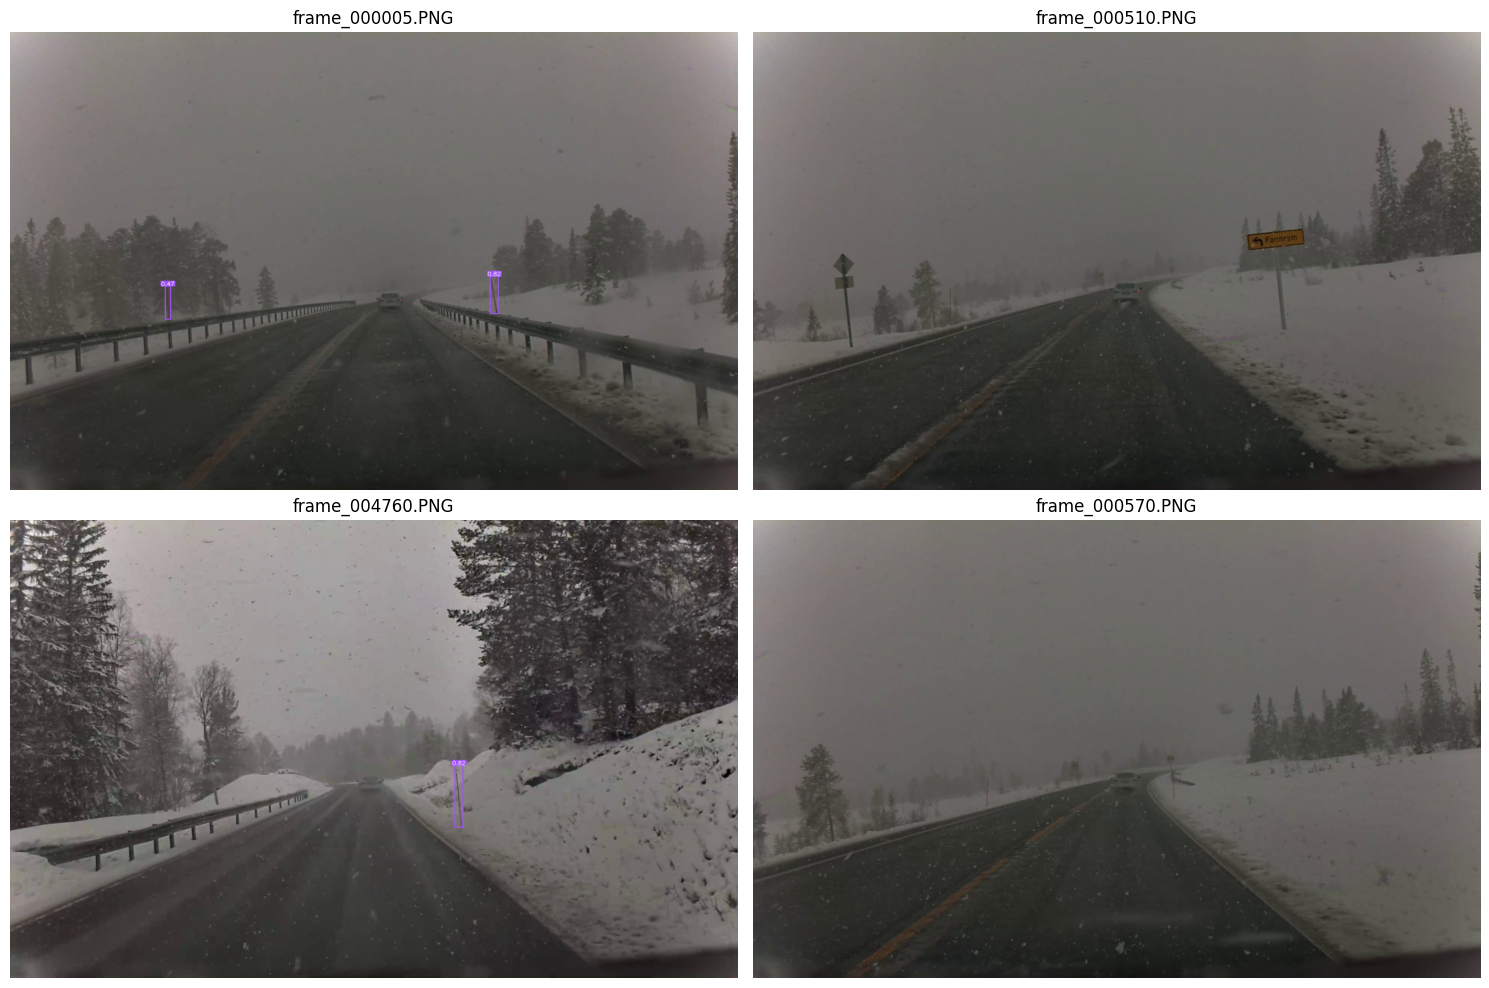

Processed 46 images
Results saved to: /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/results/v12_s_custom_loss_weight=100_retraining


In [16]:
import numpy as np
# Create annotators for visualization
bounding_box_annotator = sv.BoundingBoxAnnotator()
# For older versions of supervision, use a simpler approach without custom formatters
label_annotator = sv.LabelAnnotator(
    text_position=sv.Position.TOP_CENTER,
    text_scale=0.5,
    text_thickness=1,
    text_padding=1
)

# Process all test images
print(f"Processing {len(test_images)} test images...")
for image_path in tqdm(test_images):
    # Load and process the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not load {image_path}")
        continue
    
    # Make predictions
    results = model(image)[0]
    
    # Extract confidence values from results
    boxes_data = results.boxes.data.cpu().numpy()
    
    # Create detections with custom class names (using confidence values as labels)
    confidence_labels = [f"{conf:.2f}" for conf in boxes_data[:, 4]]
    
    # Create detections with custom class names
    detections = sv.Detections.from_ultralytics(results)
    detections.class_id = np.zeros_like(detections.class_id)  # Reset class IDs to 0
    
    # Set confidence values as the class names
    class_names = {0: ""}  # Empty string as base class name
    
    # Apply annotations
    annotated_image = bounding_box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(
        scene=annotated_image, 
        detections=detections,
        labels=confidence_labels
    )
    
    # Save the image result
    image_filename = Path(image_path).name
    output_path = os.path.join(output_dir, f"detection_{image_filename}")
    cv2.imwrite(output_path, annotated_image)

print(f"All results saved to {output_dir}")

# Optionally display a montage of some results (first 4 images)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, image_path in enumerate(test_images[:4]):
    if i >= 4:  # Limit to first 4 images
        break
        
    # Load the saved result
    image_filename = Path(image_path).name
    result_path = os.path.join(output_dir, f"detection_{image_filename}")
    
    if os.path.exists(result_path):
        result_img = cv2.imread(result_path)
        result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(result_img_rgb)
        axes[i].set_title(f"{image_filename}")
        axes[i].axis('off')
    
plt.tight_layout()
plt.show()

# Print summary 
print(f"Processed {len(test_images)} images")
print(f"Results saved to: {output_dir}")

In [17]:
import os
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm
import numpy as np
import datetime

# Thresholds (clearly defined at the top)
CONFIDENCE_THRESHOLD = 0.5  # Confidence threshold for predictions
IOU_THRESHOLD = 0.5         # IoU threshold for determining true positives

# Define confidence distribution buckets
confidence_distribution = {f"{i/10:.1f}-{(i+1)/10:.1f}": 0 for i in range(10)}

# Evaluation metrics
true_positives = 0
false_positives = 0
false_negatives = 0
total_gt_objects = 0

def calculate_iou(box1, box2):
    """Calculate IoU between two boxes [x1, y1, x2, y2]"""
    # Calculate intersection area
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    if x2 < x1 or y2 < y1:
        return 0.0
    
    intersection = (x2 - x1) * (y2 - y1)
    
    # Calculate union area
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = box1_area + box2_area - intersection
    
    return intersection / union if union > 0 else 0

# Process test images
for img_path in tqdm(valid_images):
    # Extract the base name from the full path correctly
    base_name = Path(img_path).stem  # This gets just the filename without extension
    label_path = os.path.join(valid_label_dir, f"{base_name}.txt")
    
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load {img_path}")
        continue
    
    # Get original image dimensions
    h_orig, w_orig = img.shape[:2]
    
    # Load ground truth labels
    gt_boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:  # class, x_center, y_center, width, height (normalized)
                    class_id = int(parts[0])
                    x_center = float(parts[1]) * w_orig
                    y_center = float(parts[2]) * h_orig
                    width = float(parts[3]) * w_orig
                    height = float(parts[4]) * h_orig
                    
                    # Convert to [x1, y1, x2, y2] format
                    x1 = x_center - width / 2
                    y1 = y_center - height / 2
                    x2 = x_center + width / 2
                    y2 = y_center + height / 2
                    
                    gt_boxes.append([x1, y1, x2, y2, class_id])
    
    total_gt_objects += len(gt_boxes)
    
    # Run inference with the model
    results = model.predict(img_path, conf=CONFIDENCE_THRESHOLD, verbose=False)
    
    # Extract predictions
    pred_boxes = []
    if len(results) > 0 and hasattr(results[0].boxes, 'data'):
        boxes_data = results[0].boxes.data.cpu().numpy()
        for box in boxes_data:
            x1, y1, x2, y2, conf, cls_id = box
            
            # Record confidence distribution
            conf_val = float(conf)
            conf_bucket = min(int(conf_val * 10), 9)
            conf_range = f"{conf_bucket/10:.1f}-{(conf_bucket+1)/10:.1f}"
            confidence_distribution[conf_range] += 1
            
            pred_boxes.append([float(x1), float(y1), float(x2), float(y2), float(conf), int(cls_id)])
    
    # Evaluate predictions against ground truth
    matched_gt = [False] * len(gt_boxes)
    
    for pred_box in pred_boxes:
        x1, y1, x2, y2, conf, cls_id = pred_box
        pred_bbox = [x1, y1, x2, y2]
        
        best_iou = 0
        best_gt_idx = -1
        
        # Find the best matching ground truth box
        for i, gt_box in enumerate(gt_boxes):
            if matched_gt[i]:
                continue  # Skip already matched ground truth boxes
                
            gt_bbox = gt_box[:4]
            iou = calculate_iou(pred_bbox, gt_bbox)
            
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = i
        
        # Check if prediction is a true positive or false positive
        if best_iou >= IOU_THRESHOLD:
            true_positives += 1
            if best_gt_idx >= 0:
                matched_gt[best_gt_idx] = True
        else:
            false_positives += 1
    
    # Count false negatives (unmatched ground truth boxes)
    false_negatives += matched_gt.count(False)

# Calculate metrics
precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Calculate additional metrics
miss_rate = false_negatives / total_gt_objects if total_gt_objects > 0 else float('nan')
fdr = false_positives / (false_positives + true_positives) if (false_positives + true_positives) > 0 else float('nan')
total_accuracy = true_positives / (total_gt_objects + false_positives) if (total_gt_objects + false_positives) > 0 else float('nan')

# Print results
print("\nEvaluation Results:")
print(f"Total test images: {len(valid_images)}")
print(f"Total ground truth objects: {total_gt_objects}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}, IoU threshold: {IOU_THRESHOLD}")
print(f"True positives: {true_positives}")
print(f"False positives: {false_positives}")
print(f"False negatives: {false_negatives}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")
print(f"Miss rate: {miss_rate:.4f}")
print(f"False discovery rate: {fdr:.4f}")
print(f"Total accuracy: {total_accuracy:.4f}")

# Print confidence distribution
print("\nConfidence Distribution:")
for conf_range, count in sorted(confidence_distribution.items()):
    print(f"  {conf_range}: {count} predictions")

# Save results to text file with timestamp
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
eval_results_path = os.path.join(output_dir, f"model_evaluation_results_{timestamp}.txt")

with open(eval_results_path, 'w') as f:
    f.write("===== YOLOv12 Model Evaluation Results =====\n")
    f.write(f"Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Model: {str(model.ckpt_path)}\n\n")
    
    f.write("===== Basic Metrics =====\n")
    f.write(f"Total ground truth boxes: {total_gt_objects}\n")
    f.write(f"Total predictions: {true_positives + false_positives}\n")
    f.write(f"True positives: {true_positives}\n")
    f.write(f"False positives: {false_positives}\n")
    f.write(f"False negatives: {false_negatives}\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1 Score: {f1_score:.4f}\n\n")
    
    f.write("===== Additional Metrics =====\n")
    if not np.isnan(miss_rate):
        f.write(f"Miss rate: {miss_rate:.4f}\n")
    else:
        f.write("Miss rate: N/A\n")
        
    if not np.isnan(fdr):
        f.write(f"False discovery rate: {fdr:.4f}\n")
    else:
        f.write("False discovery rate: N/A\n")
        
    if not np.isnan(total_accuracy):
        f.write(f"Total accuracy: {total_accuracy:.4f}\n")
    else:
        f.write("Total accuracy: N/A\n")

print(f"\nEvaluation results saved to: {eval_results_path}")

100%|██████████| 92/92 [00:04<00:00, 22.48it/s]


Evaluation Results:
Total test images: 92
Total ground truth objects: 113
Confidence threshold: 0.5, IoU threshold: 0.5
True positives: 49
False positives: 1
False negatives: 64
Precision: 0.9800
Recall: 0.4336
F1 Score: 0.6012
Miss rate: 0.5664
False discovery rate: 0.0200
Total accuracy: 0.4298

Confidence Distribution:
  0.0-0.1: 0 predictions
  0.1-0.2: 0 predictions
  0.2-0.3: 0 predictions
  0.3-0.4: 0 predictions
  0.4-0.5: 0 predictions
  0.5-0.6: 5 predictions
  0.6-0.7: 14 predictions
  0.7-0.8: 21 predictions
  0.8-0.9: 9 predictions
  0.9-1.0: 1 predictions

Evaluation results saved to: /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/results/v12_s_custom_loss_weight=100_retraining/model_evaluation_results_20250418_115955.txt


### Visualize all rejected bounding boxes

Total potential boxes: 47460
Actual detected boxes (very low conf): 26
Final detections: 2


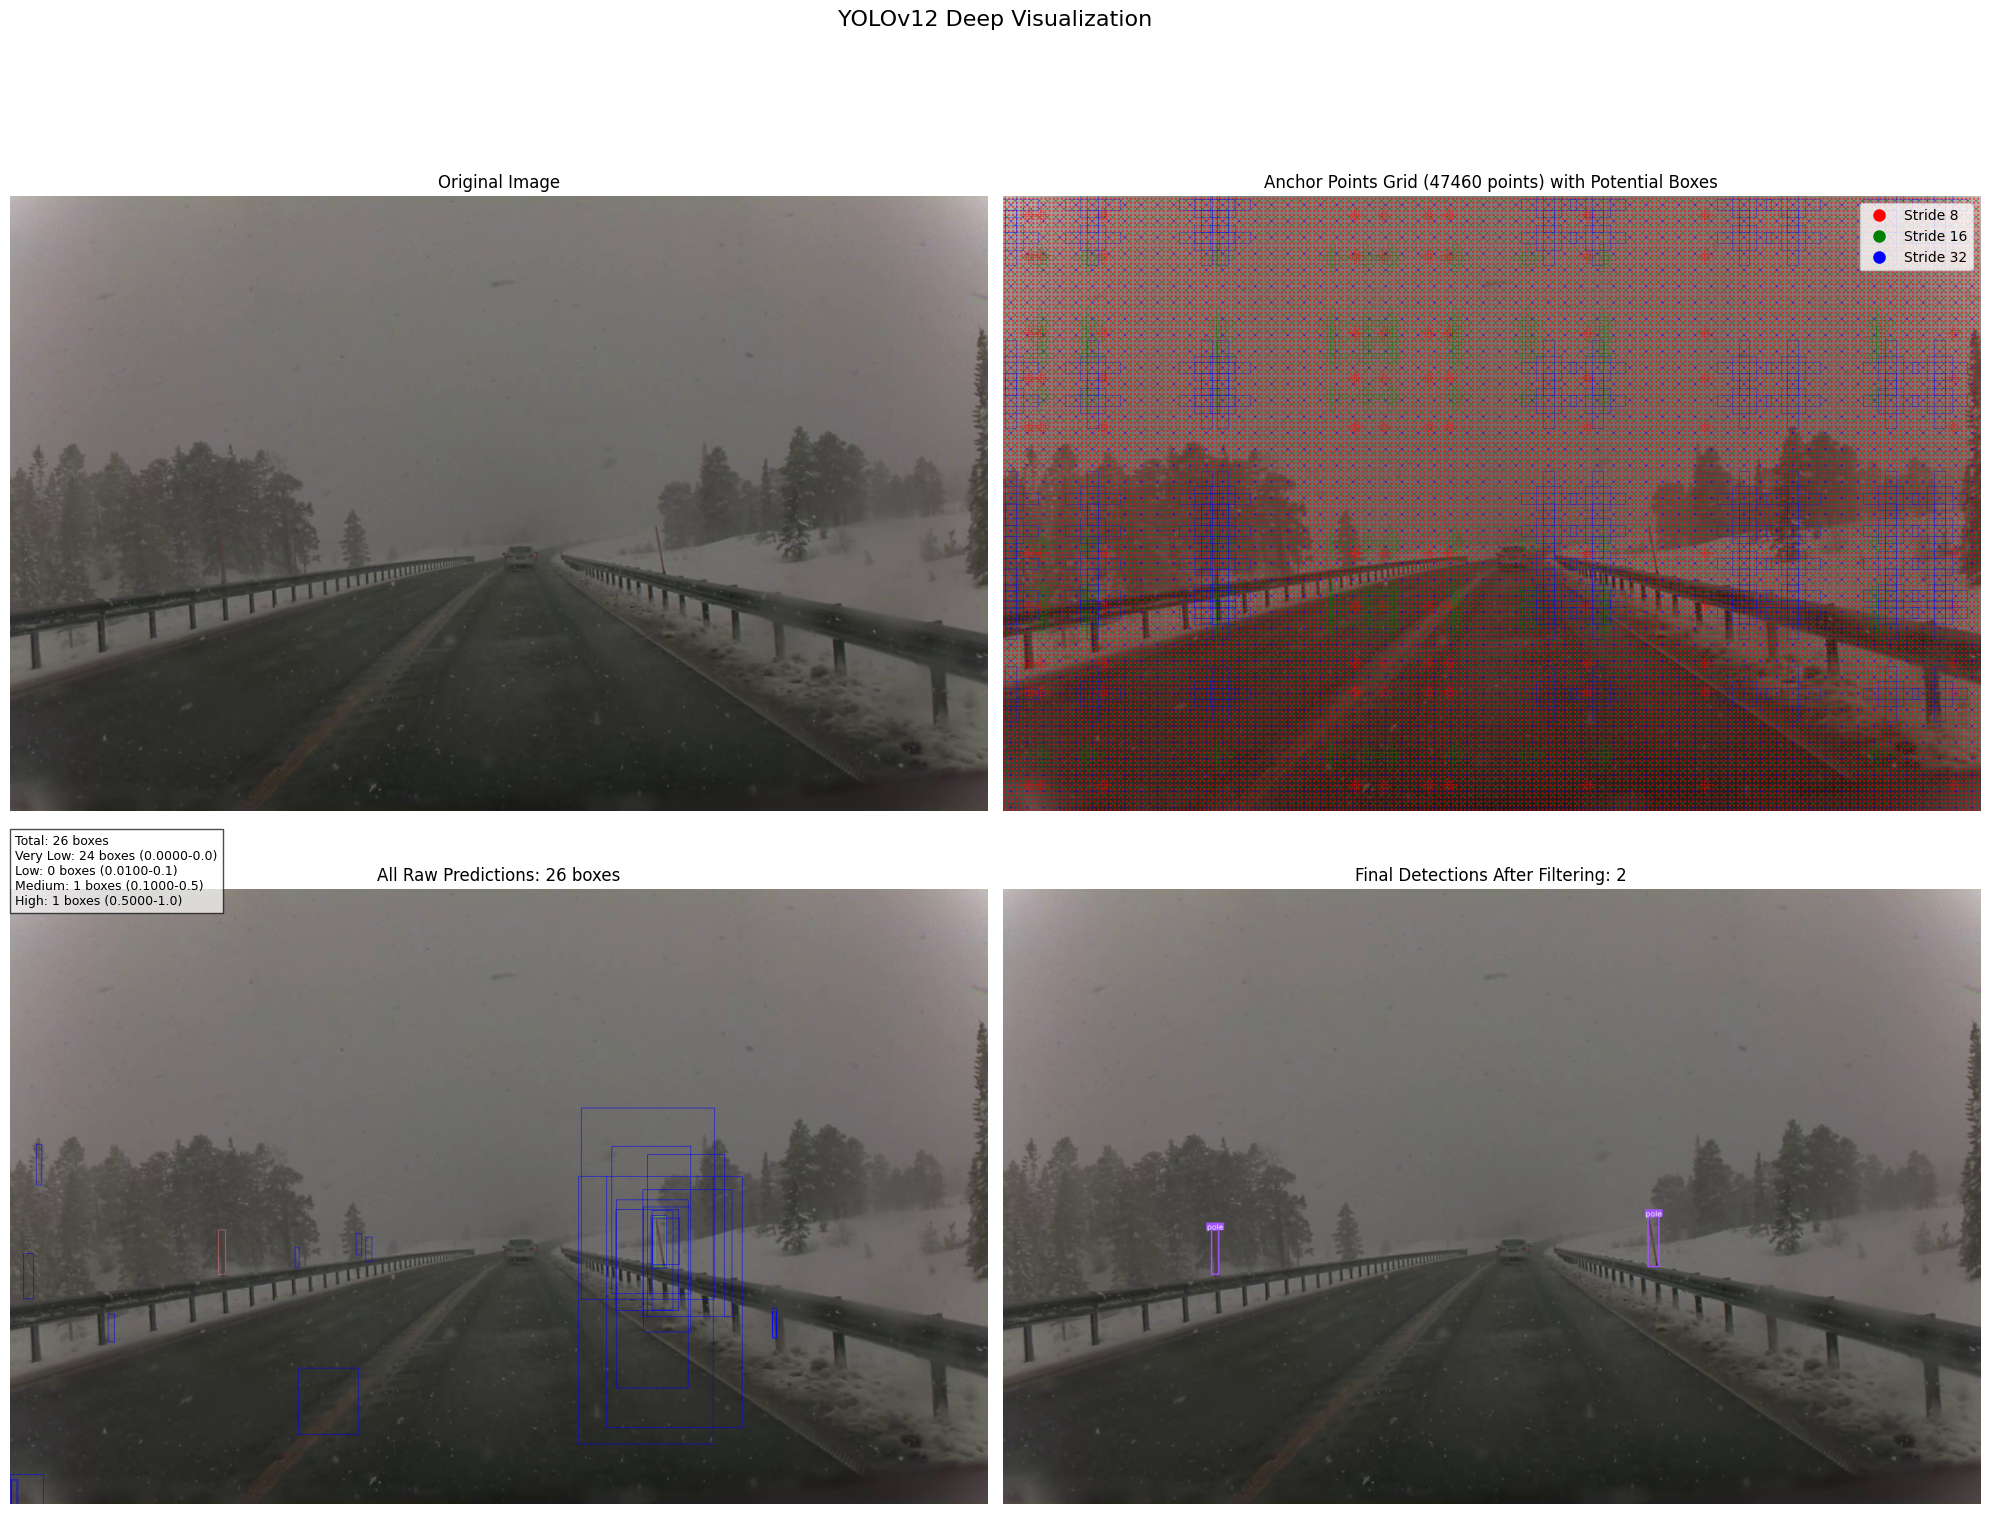

Found 26 candidate boxes total
Visualization saved to /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12_our_files/results/v12_s_custom_loss_weight=100_retraining
Total potential boxes: 47460
Actual detected boxes (very low conf): 12
Final detections: 0
Image 2: Found 12 candidate boxes


In [18]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics.utils.tal import make_anchors

def visualize_feature_maps_and_boxes(image_path, model, conf_threshold=0.00001):
    """
    Visualize YOLOv12's detection process at a lower level:
    1. Original image
    2. All potential boxes based on anchor points
    3. Feature activation maps
    
    Args:
        image_path: Path to the image
        model: YOLO model
        conf_threshold: Extremely low threshold to see all possible candidates
    """
    # Load image
    image = cv2.imread(image_path)
    original_image = image.copy()
    h, w = image.shape[:2]
    
    # Create figure with 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle(f"YOLOv12 Deep Visualization", fontsize=16)
    
    # 1. Original image (top-left)
    axes[0, 0].imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis('off')
    
    # 2. Anchor points with primitive boxes (top-right)
    # Get the feature maps and stride info from the model
    stride = model.model.stride
    features = [torch.zeros(1, 3, h // int(s), w // int(s)) for s in stride]
    
    # Generate anchors similar to how YOLOv12 does internally
    anchor_points, stride_tensor = make_anchors(features, stride)
    anchor_points = anchor_points.cpu().numpy()
    
    # Plot anchor points on original image with potential boxes
    anchor_img = original_image.copy()
    axes[0, 1].imshow(cv2.cvtColor(anchor_img, cv2.COLOR_BGR2RGB))
    
    # Draw grid for each stride with different colors and sample boxes
    colors = ['red', 'green', 'blue', 'yellow', 'cyan']
    legend_elements = []
    
    # Draw sample potential boxes at each anchor point
    # These are theoretical boxes before any prediction happens
    for i, s in enumerate(stride):
        s = int(s)
        color = colors[i % len(colors)]
        
        # Create grid points for this stride
        x_points = np.arange(s//2, w, s)
        y_points = np.arange(s//2, h, s)
        
        # Sample some points to avoid overcrowding (10% of points)
        np.random.seed(42)  # For reproducibility
        sample_size = max(1, int(0.1 * len(x_points) * len(y_points)))
        x_samples = np.random.choice(x_points, min(10, len(x_points)), replace=False)
        y_samples = np.random.choice(y_points, min(10, len(y_points)), replace=False)
        
        # Draw anchor points
        for x in x_points:
            for y in y_points:
                axes[0, 1].add_patch(plt.Circle((x, y), radius=1, color=color, alpha=0.5))
                
        # Draw sample bounding boxes at selected anchor points
        # Using multiple aspect ratios to show potential boxes (thin, medium, wide)
        aspect_ratios = [0.2, 1.0, 5.0]  # width/height ratios
        
        for x in x_samples:
            for y in y_samples:
                for ratio in aspect_ratios:
                    # Size proportional to stride
                    width = s * np.sqrt(ratio) * 1.5
                    height = s / np.sqrt(ratio) * 1.5
                    
                    rect = plt.Rectangle(
                        (x - width/2, y - height/2),
                        width, height,
                        linewidth=0.5,
                        edgecolor=color,
                        facecolor='none',
                        alpha=0.4
                    )
                    axes[0, 1].add_patch(rect)
        
        legend_elements.append(plt.Line2D([0], [0], marker='o', color=color, 
                                        label=f'Stride {s}', markersize=8, linestyle='None'))
    
    axes[0, 1].legend(handles=legend_elements, loc='upper right')
    axes[0, 1].set_title(f"Anchor Points Grid ({len(anchor_points)} points) with Potential Boxes")
    axes[0, 1].axis('off')
    
    # 3. Lowest confidence predictions (bottom-left)
    # Run prediction with extremely low confidence to capture more boxes
    results_low_conf = model.predict(image_path, conf=conf_threshold, verbose=False, nms=False)
    boxes_low_conf = results_low_conf[0].boxes.data.cpu().numpy()
    
    # Draw all detected boxes from explicit prediction
    low_conf_img = original_image.copy()
    
    # Count boxes by confidence ranges
    conf_ranges = {
        'very_low': [conf_threshold, 0.01],
        'low': [0.01, 0.1],
        'medium': [0.1, 0.5], 
        'high': [0.5, 1.0]
    }
    
    box_counts = {range_name: 0 for range_name in conf_ranges}
    
    for box in boxes_low_conf:
        x1, y1, x2, y2 = map(int, box[:4])
        conf = float(box[4])
        
        # Determine confidence range
        for range_name, (min_conf, max_conf) in conf_ranges.items():
            if min_conf <= conf < max_conf:
                box_counts[range_name] += 1
                break
                
        # Color based on confidence (green to red)
        color_b = max(0, int(255 * (1-conf)))  
        color_g = max(0, int(255 * conf))
        color_r = max(0, int(255 * (0.5 - abs(conf - 0.5)) * 2))  # Peak at 0.5 conf
        
        cv2.rectangle(low_conf_img, (x1, y1), (x2, y2), (color_b, color_g, color_r), 1)
    
    axes[1, 0].imshow(cv2.cvtColor(low_conf_img, cv2.COLOR_BGR2RGB))
    
    # Create legend text for confidence ranges
    conf_text = "\n".join([
        f"{range_name.replace('_', ' ').title()}: {count} boxes ({min_conf:.4f}-{max_conf:.1f})"
        for range_name, count in box_counts.items()
        for min_conf, max_conf in [conf_ranges[range_name]]
    ])
    
    total_boxes = sum(box_counts.values())
    axes[1, 0].text(10, 30, f"Total: {total_boxes} boxes\n{conf_text}", 
                    bbox=dict(facecolor='white', alpha=0.7), fontsize=9)
    
    axes[1, 0].set_title(f"All Raw Predictions: {len(boxes_low_conf)} boxes")
    axes[1, 0].axis('off')
    
    # 4. Final filtered predictions (bottom-right)
    results = model.predict(image_path, conf=0.25, verbose=False)  # Standard filtering
    detections = sv.Detections.from_ultralytics(results[0])
    
    # Draw final boxes
    final_img = original_image.copy()
    final_img = bounding_box_annotator.annotate(scene=final_img, detections=detections)
    final_img = label_annotator.annotate(scene=final_img, detections=detections)
    
    axes[1, 1].imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title(f"Final Detections After Filtering: {len(detections)}")
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    # Save the visualization
    image_filename = Path(image_path).name
    fig_path = os.path.join(output_dir, f"deep_vis_{image_filename.split('.')[0]}.png")
    fig.savefig(fig_path, bbox_inches='tight')
    
    print(f"Total potential boxes: {len(anchor_points)}")
    print(f"Actual detected boxes (very low conf): {total_boxes}")
    print(f"Final detections: {len(detections)}")
    
    return fig, total_boxes

# Run visualization with extremely low confidence to see more boxes
example_image_path = test_images[0]
fig, box_count = visualize_feature_maps_and_boxes(example_image_path, model, conf_threshold=0.00001)
plt.show()

print(f"Found {box_count} candidate boxes total")
print(f"Visualization saved to {output_dir}")

# Try with one more image
if len(test_images) > 1:
    fig, count = visualize_feature_maps_and_boxes(test_images[1], model, conf_threshold=0.00001)
    print(f"Image 2: Found {count} candidate boxes")
    plt.close(fig)

### Aspect ration analysis for 1 image

Getting predictions with very low confidence threshold...

=== Bounding Box Aspect Ratio Analysis ===
Total boxes analyzed: 26

Category distribution:
  very_tall: 14 boxes (53.8%) - AR range: 0.00 to 0.33
  slightly_tall: 2 boxes (7.7%) - AR range: 0.67 to 0.90
  tall: 8 boxes (30.8%) - AR range: 0.33 to 0.67
  slightly_wide: 1 boxes (3.8%) - AR range: 1.10 to 1.50
  square: 1 boxes (3.8%) - AR range: 0.90 to 1.10

Statistical summary:
  Mean aspect ratio: 0.40
  Median aspect ratio: 0.28
  Standard deviation: 0.25
  Min aspect ratio: 0.14
  Max aspect ratio: 1.12


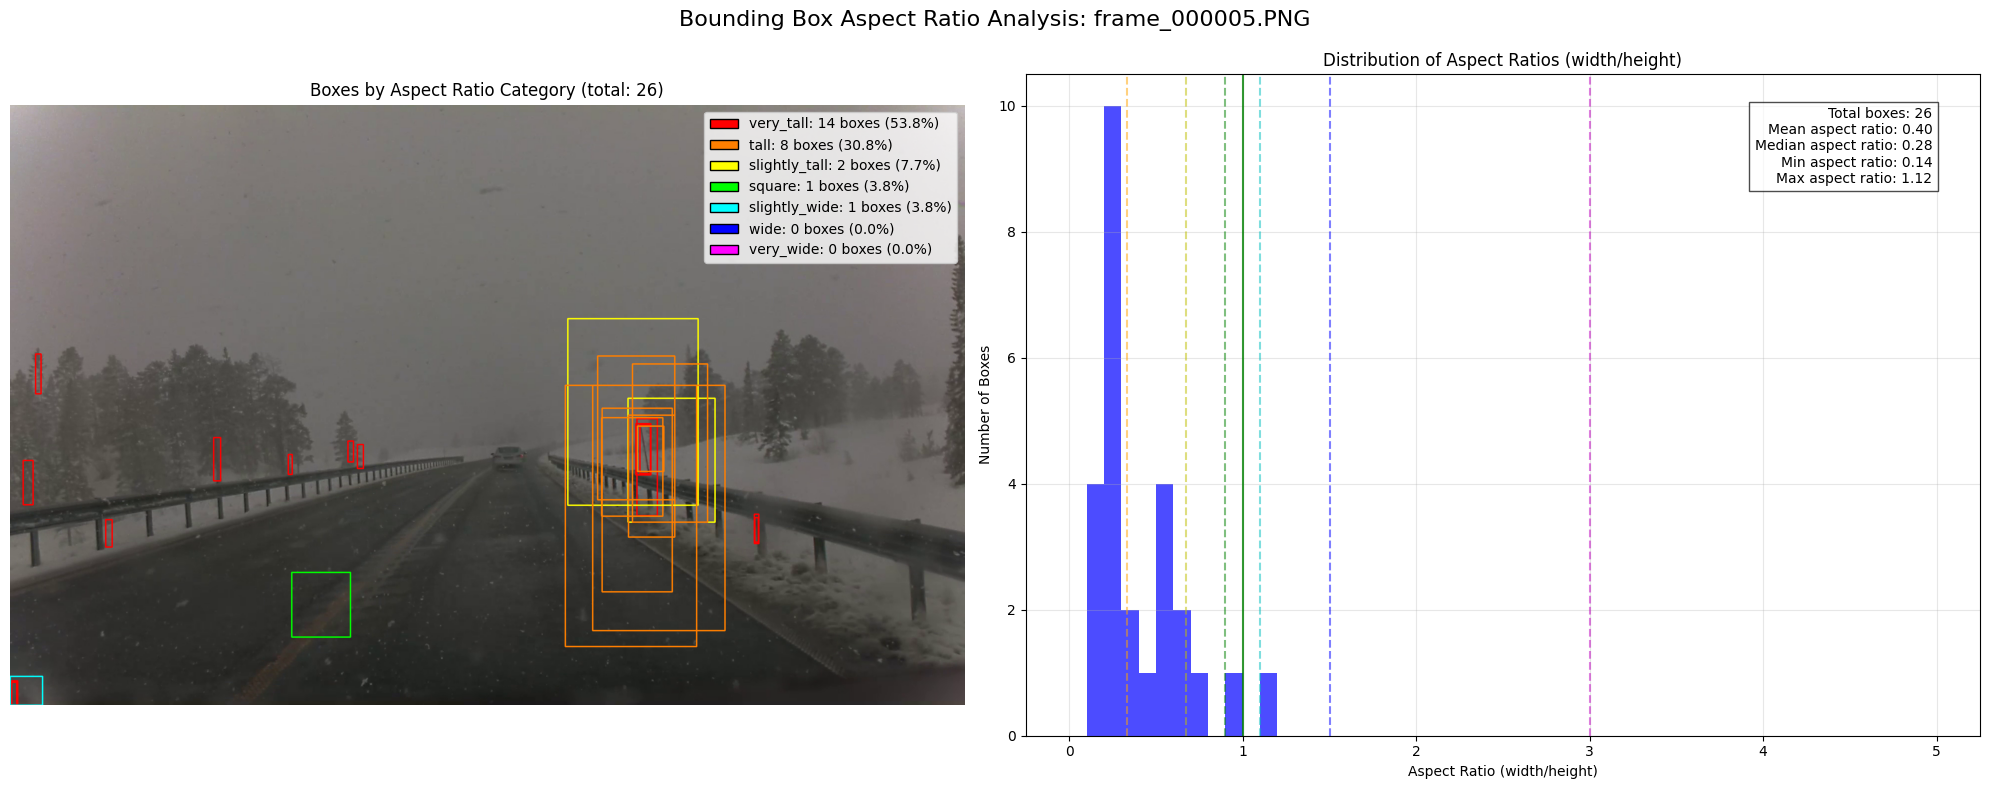

Getting predictions with very low confidence threshold...

=== Bounding Box Aspect Ratio Analysis ===
Total boxes analyzed: 12

Category distribution:
  very_tall: 8 boxes (66.7%) - AR range: 0.00 to 0.33
  tall: 2 boxes (16.7%) - AR range: 0.33 to 0.67
  slightly_tall: 1 boxes (8.3%) - AR range: 0.67 to 0.90
  slightly_wide: 1 boxes (8.3%) - AR range: 1.10 to 1.50

Statistical summary:
  Mean aspect ratio: 0.37
  Median aspect ratio: 0.24
  Standard deviation: 0.34
  Min aspect ratio: 0.07
  Max aspect ratio: 1.26


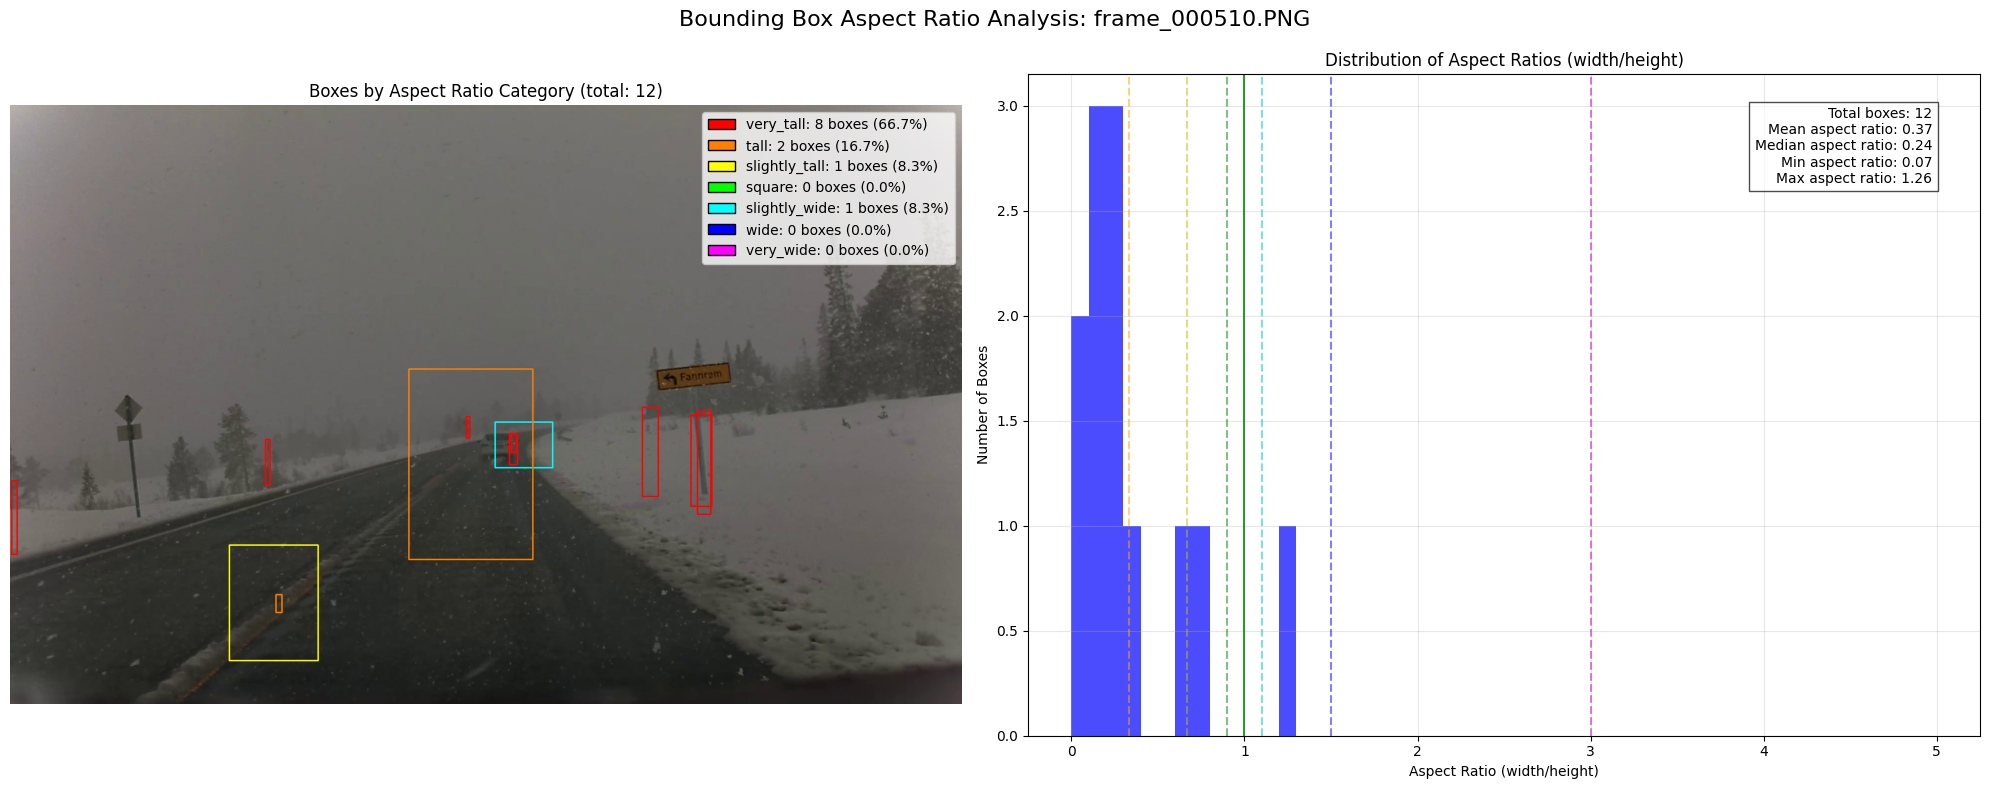

In [19]:
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

def analyze_box_aspect_ratios(image_path, model, conf_threshold=0.00001):
    """
    Analyze and visualize aspect ratios of the detected bounding boxes.
    
    Args:
        image_path: Path to the image
        model: YOLO model
        conf_threshold: Threshold for box detection
    """
    # Load image
    image = cv2.imread(image_path)
    original_image = image.copy()
    h, w = image.shape[:2]
    
    # Run prediction with extremely low confidence to capture all boxes
    print("Getting predictions with very low confidence threshold...")
    results_low_conf = model.predict(image_path, conf=conf_threshold, verbose=False, nms=False)
    boxes_low_conf = results_low_conf[0].boxes.data.cpu().numpy()
    
    # Calculate aspect ratios for all boxes
    aspect_ratios = []
    for box in boxes_low_conf:
        x1, y1, x2, y2 = map(int, box[:4])
        width = x2 - x1
        height = y2 - y1
        # Avoid division by zero
        if height == 0:
            continue
        aspect_ratio = width / height
        aspect_ratios.append(aspect_ratio)
    
    # Define aspect ratio categories
    categories = {
        'very_tall': (0, 0.33),     # height is 3x+ width
        'tall': (0.33, 0.67),       # height is 1.5x to 3x width
        'slightly_tall': (0.67, 0.9), # height slightly larger than width
        'square': (0.9, 1.1),       # roughly square
        'slightly_wide': (1.1, 1.5), # width slightly larger than height
        'wide': (1.5, 3.0),        # width is 1.5x to 3x height
        'very_wide': (3.0, float('inf')) # width is 3x+ height
    }
    
    # Categorize boxes
    categorized = defaultdict(list)
    for ar in aspect_ratios:
        for category, (min_ar, max_ar) in categories.items():
            if min_ar <= ar < max_ar:
                categorized[category].append(ar)
                break
    
    # Count categories
    category_counts = {category: len(boxes) for category, boxes in categorized.items()}
    total_boxes = len(aspect_ratios)
    
    # Create figure for visualization
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f"Bounding Box Aspect Ratio Analysis: {Path(image_path).name}", fontsize=16)
    
    # 1. Original image with all bounding boxes colored by aspect ratio
    # Create a copy of the original image
    aspect_ratio_image = original_image.copy()
    
    # Color mapping for categories
    color_map = {
        'very_tall': (0, 0, 255),     # Red
        'tall': (0, 127, 255),         # Orange
        'slightly_tall': (0, 255, 255), # Yellow
        'square': (0, 255, 0),         # Green
        'slightly_wide': (255, 255, 0), # Cyan
        'wide': (255, 0, 0),           # Blue
        'very_wide': (255, 0, 255)      # Magenta
    }
    
    # Draw boxes with category-based coloring
    for box in boxes_low_conf:
        x1, y1, x2, y2 = map(int, box[:4])
        width = x2 - x1
        height = y2 - y1
        
        # Avoid division by zero
        if height == 0:
            continue
            
        aspect_ratio = width / height
        
        # Determine category
        box_category = None
        for category, (min_ar, max_ar) in categories.items():
            if min_ar <= aspect_ratio < max_ar:
                box_category = category
                break
                
        # Get color based on category
        color = color_map.get(box_category, (255, 255, 255))
        
        # Draw rectangle
        cv2.rectangle(aspect_ratio_image, (x1, y1), (x2, y2), color, 2)
    
    # Display image
    axes[0].imshow(cv2.cvtColor(aspect_ratio_image, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Boxes by Aspect Ratio Category (total: {total_boxes})")
    axes[0].axis('off')
    
    # Create legend for categories
    legend_elements = []
    for category, color in color_map.items():
        # Convert BGR to RGB for matplotlib
        color_rgb = (color[2]/255, color[1]/255, color[0]/255)
        count = len(categorized[category])
        percentage = (count / total_boxes * 100) if total_boxes > 0 else 0
        
        # Create patch for legend
        patch = plt.Rectangle((0, 0), 1, 1, facecolor=color_rgb, edgecolor='black')
        legend_elements.append((patch, f"{category}: {count} boxes ({percentage:.1f}%)"))
    
    # Add legend to first subplot
    legend_patches = [item[0] for item in legend_elements]
    legend_labels = [item[1] for item in legend_elements]
    axes[0].legend(legend_patches, legend_labels, loc='upper right')
    
    # 2. Histogram of aspect ratios
    axes[1].hist(aspect_ratios, bins=50, range=(0, 5), alpha=0.7, color='blue')
    axes[1].set_title(f"Distribution of Aspect Ratios (width/height)")
    axes[1].set_xlabel("Aspect Ratio (width/height)")
    axes[1].set_ylabel("Number of Boxes")
    axes[1].grid(alpha=0.3)
    
    # Add vertical lines for category boundaries
    colors = ['r', 'orange', 'y', 'g', 'c', 'b', 'm']
    for i, (category, (min_val, max_val)) in enumerate(categories.items()):
        if min_val > 0:
            axes[1].axvline(x=min_val, color=colors[i % len(colors)], linestyle='--', alpha=0.5)
    
    # Add vertical line at aspect ratio = 1 (square)
    axes[1].axvline(x=1.0, color='g', linestyle='-', alpha=0.8, label="Square (AR=1)")
    
    # Add text showing statistics
    stats_text = "\n".join([
        f"Total boxes: {total_boxes}",
        f"Mean aspect ratio: {np.mean(aspect_ratios):.2f}",
        f"Median aspect ratio: {np.median(aspect_ratios):.2f}",
        f"Min aspect ratio: {min(aspect_ratios):.2f}",
        f"Max aspect ratio: {max(aspect_ratios):.2f}"
    ])
    axes[1].text(0.95, 0.95, stats_text, 
                transform=axes[1].transAxes, 
                fontsize=10, 
                bbox=dict(facecolor='white', alpha=0.7),
                verticalalignment='top', 
                horizontalalignment='right')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    
    # Save the visualization
    image_filename = Path(image_path).name
    fig_path = os.path.join(output_dir, f"aspect_ratio_analysis_{image_filename.split('.')[0]}.png")
    fig.savefig(fig_path, bbox_inches='tight')
    
    # Print summary statistics
    print("\n=== Bounding Box Aspect Ratio Analysis ===")
    print(f"Total boxes analyzed: {total_boxes}")
    print("\nCategory distribution:")
    for category, count in category_counts.items():
        percentage = (count / total_boxes * 100) if total_boxes > 0 else 0
        min_val, max_val = categories[category]
        print(f"  {category}: {count} boxes ({percentage:.1f}%) - AR range: {min_val:.2f} to {max_val:.2f}")
    
    print("\nStatistical summary:")
    print(f"  Mean aspect ratio: {np.mean(aspect_ratios):.2f}")
    print(f"  Median aspect ratio: {np.median(aspect_ratios):.2f}")
    print(f"  Standard deviation: {np.std(aspect_ratios):.2f}")
    print(f"  Min aspect ratio: {min(aspect_ratios):.2f}")
    print(f"  Max aspect ratio: {max(aspect_ratios):.2f}")
    
    return aspect_ratios, categorized, fig

# Run the aspect ratio analysis
example_image_path = test_images[0]
aspect_ratios, categorized_boxes, fig = analyze_box_aspect_ratios(example_image_path, model, conf_threshold=0.00001)
plt.show()

# Try with one more image if available
if len(test_images) > 1:
    aspect_ratios2, categorized_boxes2, fig2 = analyze_box_aspect_ratios(test_images[1], model, conf_threshold=0.00001)
    plt.show()